In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import keras_tuner as kt

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.regularizers import l2

In [2]:
# =========================================================
# SETTINGS
# =========================================================

DATASET_DIR = r"C:\Users\ADMIN\Solar Panel Classification\data"

IMG_HEIGHT = 224
IMG_WIDTH = 224

BATCH_SIZE = 32
SEED = 42

In [3]:
# =========================================================
# LOAD DATASET
# =========================================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 885 files belonging to 6 classes.
Using 708 files for training.
Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [4]:
# =========================================================
# CLASS NAMES
# =========================================================

class_names = train_dataset.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
Number of classes: 6


In [5]:
# =========================================================
# CACHE + PREFETCH
# =========================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)

In [6]:
# =========================================================
# CLASS WEIGHTS
# =========================================================

class_counts = {}
total_images = 0

for class_name in class_names:

    class_path = os.path.join(DATASET_DIR, class_name)

    count = len(os.listdir(class_path))

    class_counts[class_name] = count

    total_images += count

class_weights = {}

for index, class_name in enumerate(class_names):

    class_weights[index] = (
        total_images / (num_classes * class_counts[class_name])
    )

print("Class Weights:", class_weights)

Class Weights: {0: 0.7564766839378239, 1: 0.7525773195876289, 2: 0.7643979057591623, 3: 1.4038461538461537, 4: 2.085714285714286, 5: 1.1774193548387097}


In [7]:
# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([

    RandomFlip("horizontal"),

    RandomRotation(0.1),

    RandomZoom(0.15),

    RandomContrast(0.1)

])

In [8]:
# =========================================================
# BUILD MODEL
# =========================================================

inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

x = data_augmentation(inputs)

# IMPORTANT
# DO NOT USE Rescaling WITH EfficientNet

x = preprocess_input(x)

base_model = EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_tensor=x
)

# Freeze base model initially
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dropout(0.3)(x)

x = Dense(
    256,
    activation="relu",
    kernel_regularizer=l2(0.0005)
)(x)

x = Dropout(0.4)(x)

outputs = Dense(
    num_classes,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [9]:
# =========================================================
# COMPILE MODEL
# =========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [10]:
# =========================================================
# MODEL SUMMARY
# =========================================================

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential (Sequential)       │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ sequential[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
# =========================================================
# CALLBACKS
# =========================================================

callbacks = [

    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [12]:
# =========================================================
# INITIAL TRAINING
# =========================================================

history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=15,

    class_weight=class_weights,

    callbacks=callbacks
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.3238 - loss: 1.9074
Epoch 1: val_accuracy improved from None to 0.59887, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 690ms/step - accuracy: 0.4195 - loss: 1.6824 - val_accuracy: 0.5989 - val_loss: 1.2822 - learning_rate: 0.0010
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.6451 - loss: 1.2129
Epoch 2: val_accuracy improved from 0.59887 to 0.71751, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 557ms/step - accuracy: 0.6554 - loss: 1.1676 - val_accuracy: 0.7175 - val_loss: 1.0127 - learning_rate: 0.0010
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.7007 - loss: 0.9714
Epoch 3: val_accuracy improved from 0.71751 to 0.73446, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 595ms/s

In [13]:
# =========================================================
# FINE TUNING
# =========================================================

print("\nStarting Fine Tuning...\n")

base_model.trainable = True

# Freeze early layers
for layer in base_model.layers[:-20]:

    layer.trainable = False

# Recompile with lower LR

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-6
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

history_fine = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=15,

    class_weight=class_weights,

    callbacks=callbacks
)


Starting Fine Tuning...

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.5985 - loss: 1.1681
Epoch 1: val_accuracy did not improve from 0.79096
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 809ms/step - accuracy: 0.6201 - loss: 1.1386 - val_accuracy: 0.7910 - val_loss: 0.7997 - learning_rate: 1.0000e-06
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.6062 - loss: 1.1444
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.999999992425728e-07.

Epoch 2: val_accuracy did not improve from 0.79096
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 699ms/step - accuracy: 0.6045 - loss: 1.1497 - val_accuracy: 0.7740 - val_loss: 0.8235 - learning_rate: 1.0000e-06
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.6166 - loss: 1.1461
Epoch 3: val_accuracy did not improve from 0.79096
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 677ms/step - accuracy: 0.6031 - loss: 1.1773 - val_accuracy: 0.7627 - val_loss: 0.8706 - learning_rate: 3.0000e-07
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/s

In [14]:
# =========================================================
# SAVE MODEL
# =========================================================

model.save("solar_panel_classifier_best.keras")

print("\nModel Saved Successfully!")


Model Saved Successfully!


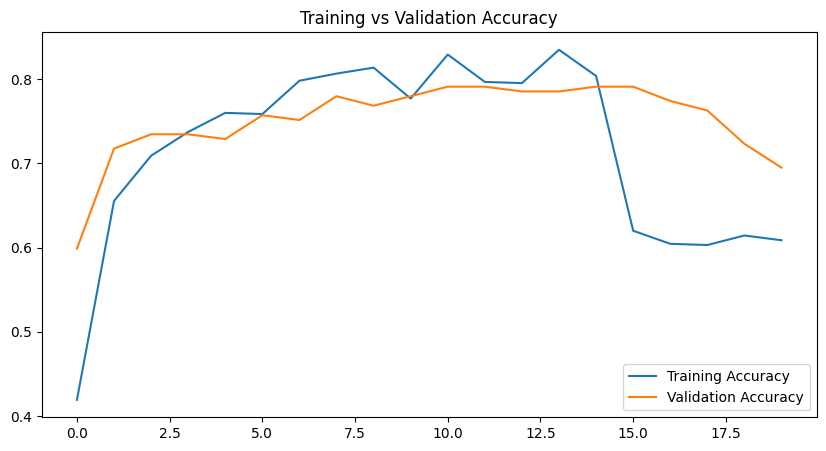

In [15]:
# =========================================================
# PLOT ACCURACY
# =========================================================

acc = history.history['accuracy'] + history_fine.history['accuracy']

val_acc = (
    history.history['val_accuracy']
    + history_fine.history['val_accuracy']
)

epochs_range = range(len(acc))

plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    acc,
    label='Training Accuracy'
)

plt.plot(
    epochs_range,
    val_acc,
    label='Validation Accuracy'
)

plt.legend(loc='lower right')

plt.title('Training vs Validation Accuracy')

plt.show()

In [16]:
# =========================================================
# HYPERPARAMETER TUNING
# =========================================================

def build_model(hp):

    inputs = Input(shape=(224,224,3))

    data_aug = tf.keras.Sequential([

        RandomFlip("horizontal"),

        RandomRotation(
            hp.Float(
                "rotation",
                0.05,
                0.20,
                step=0.05
            )
        ),

        RandomZoom(
            hp.Float(
                "zoom",
                0.05,
                0.20,
                step=0.05
            )
        ),

        RandomContrast(
            hp.Float(
                "contrast",
                0.05,
                0.20,
                step=0.05
            )
        )
    ])

    x = data_aug(inputs)

    x = preprocess_input(x)

    base_model = EfficientNetB0(

        include_top=False,

        weights="imagenet",

        input_tensor=x
    )

    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)

    x = Dropout(
        hp.Float(
            "dropout_1",
            0.2,
            0.5,
            step=0.1
        )
    )(x)

    x = Dense(

        hp.Int(
            "dense_units",
            128,
            512,
            step=128
        ),

        activation="relu",

        kernel_regularizer=l2(

            hp.Float(
                "l2",
                1e-5,
                1e-3,
                sampling="log"
            )
        )
    )(x)

    x = Dropout(
        hp.Float(
            "dropout_2",
            0.2,
            0.5,
            step=0.1
        )
    )(x)

    outputs = Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = Model(inputs, outputs)

    model.compile(

        optimizer=tf.keras.optimizers.Adam(

            learning_rate=hp.Float(
                "learning_rate",
                1e-5,
                1e-3,
                sampling="log"
            )
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model

In [17]:
# =========================================================
# TUNER
# =========================================================

tuner = kt.RandomSearch(

    build_model,

    objective='val_accuracy',

    max_trials=5,

    executions_per_trial=1,

    directory='kt_dir',

    project_name='solar_panel_tuning',

    overwrite=True
)

In [18]:
# =========================================================
# RUN TUNER
# =========================================================

tuner.search(

    train_dataset,

    validation_data=validation_dataset,

    epochs=10,

    class_weight=class_weights,

    callbacks=[

        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Trial 5 Complete [00h 02m 46s]
val_accuracy: 0.3785310685634613

Best val_accuracy So Far: 0.7457627058029175
Total elapsed time: 00h 33m 52s


In [19]:
# =========================================================
# BEST HYPERPARAMETERS
# =========================================================

best_hps = tuner.get_best_hyperparameters(1)[0]

print("\nBest Hyperparameters:\n")

print(best_hps.values)


Best Hyperparameters:

{'rotation': 0.1, 'zoom': 0.15000000000000002, 'contrast': 0.05, 'dropout_1': 0.2, 'dense_units': 384, 'l2': 4.35807341230428e-05, 'dropout_2': 0.2, 'learning_rate': 0.00017036374364839458}


In [20]:
# =========================================================
# BEST MODEL
# =========================================================

best_model = tuner.get_best_models(1)[0]

val_loss, val_acc = best_model.evaluate(validation_dataset)

print(f"\nBest Validation Accuracy: {val_acc:.4f}")

C:\Users\ADMIN\Solar Panel Classification\venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 383ms/step - accuracy: 0.7458 - loss: 0.7687

Best Validation Accuracy: 0.7458


In [21]:
# =========================================================
# SAVE BEST MODEL
# =========================================================

best_model.save("best_tuned_solar_model.keras")

print("\nBest Tuned Model Saved!")


Best Tuned Model Saved!


In [ ]:
# !pip install streamlit pillow